# TorchPenny Doc005: QVAE

In this example, we will reconstruct handwritten digits with a hybrid variational autoencoder [1].
The encoder is `Classical -> Quantum`, and the decoder is `Quantum -> Classical`.
This gate-based example differs from the quantum Boltzmann QVAE in [2].

## Setup

Use the TorchPenny environment with scikit-learn installed (`%pip install scikit-learn`). The digits dataset is included in scikit-learn.

In [1]:
import sys
from pathlib import Path

project_root = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "torchpenny" / "module.py").is_file()
)
sys.path.insert(0, str(project_root))


In [2]:
import torch
import pennylane as qml
import sklearn
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

from torchpenny.module import QLayer, QSubLayer
from torchpenny.lib.ansatz import RealAmplitude

seed = 7
dtype = torch.float64
torch.manual_seed(seed)
print(f"PyTorch {torch.__version__}, PennyLane {qml.__version__}, scikit-learn {sklearn.__version__}")


PyTorch 2.6.0, PennyLane 0.41.0, scikit-learn 1.9.1


## Handwritten digits

`load_digits` provides 8 x 8 grayscale images with pixel values from 0 to 16 [3]. We use the 360 images of digits 0 and 1, scaled to [0, 1].

Split the data into training, validation, and test sets (70/15/15%). Labels are used only for splitting and plotting; the reconstruction target is the input image.

In [3]:
digits = load_digits()
mask = (digits.target == 0) | (digits.target == 1)
X = torch.as_tensor(digits.data[mask] / 16.0, dtype=dtype)
labels = torch.as_tensor(digits.target[mask], dtype=torch.long)
indices = torch.arange(len(X)).numpy()

train_indices, heldout_indices = train_test_split(
    indices, test_size=0.30, random_state=seed, stratify=labels.numpy(),
)
validation_indices, test_indices = train_test_split(
    heldout_indices, test_size=0.50, random_state=seed,
    stratify=labels[heldout_indices].numpy(),
)
X_train, X_validation, X_test = X[train_indices], X[validation_indices], X[test_indices]
labels_train, labels_test = labels[train_indices], labels[test_indices]

train_loader = DataLoader(
    TensorDataset(X_train),
    batch_size=32,
    shuffle=True,
    generator=torch.Generator().manual_seed(seed),
)
print(f"Subset: {len(X)} images; train: {len(X_train)}, validation: {len(X_validation)}, test: {len(X_test)}")
print("Input shape:", tuple(X_train.shape), "| range:", (X.min().item(), X.max().item()))


Subset: 360 images; train: 252, validation: 54, test: 54
Input shape: (252, 64) | range: (0.0, 1.0)


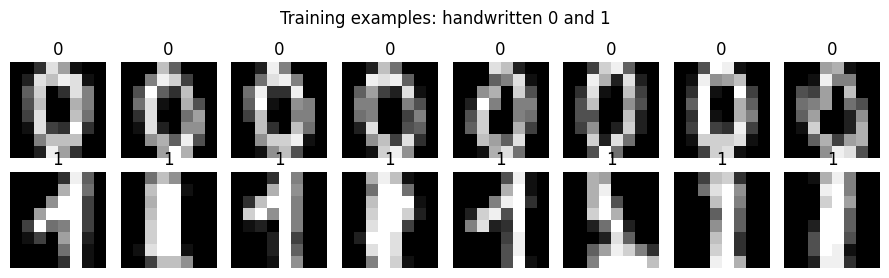

In [4]:
fig, axes = plt.subplots(2, 8, figsize=(9, 2.8))
for row, label in enumerate((0, 1)):
    examples = X_train[labels_train == label][:8]
    for col, example in enumerate(examples):
        axes[row, col].imshow(example.reshape(8, 8), cmap="gray", vmin=0, vmax=1)
        axes[row, col].set_title(str(label))
        axes[row, col].axis("off")
fig.suptitle("Training examples: handwritten 0 and 1")
fig.tight_layout()
plt.show()


## Encoder and decoder

`Image -> Classical -> Quantum -> mu, logvar -> z -> Quantum -> Classical -> Reconstruction`

The four-qubit encoder outputs Z expectations. A fixed readout produces two-dimensional posterior parameters:

- `mu = 2 * statistics[..., :2]`, bounded to [-2, 2].
- `logvar = 4 * statistics[..., 2:] - 2`, bounded to [-6, 2].

Sample the classical latent vector using reparameterization [1]:

$$z = \mu + \exp(\mathrm{logvar}/2) \odot \epsilon, \qquad \epsilon \sim \mathcal{N}(0,I).$$

The two-qubit decoder receives `z` through fixed angles `(pi/2) * tanh(z)`. There are no learned layers between the two quantum blocks and latent sampling.

## RealAmplitude ansatz

We use `RealAmplitude` for its simple RY/CNOT structure and small parameter count [4]. With `reps=2`, the encoder has 12 trainable angles and the decoder has six.

The circuits have independent weights and encode their inputs once. This is a starting ansatz, not a claim that real amplitudes are optimal for image data.

In [5]:
class RYFeatureMap(QSubLayer):
    def init_weights(self):
        # External shape metadata follows the QSubLayer (1, N) convention.
        data = torch.empty(self.wires) if self.param_received else torch.rand(self.wires)
        return data.unsqueeze(0)

    def forward(self, x=None, wires=None):
        wires = list(range(self.wires)) if wires is None else list(wires)
        if len(wires) != self.wires:
            raise ValueError("Applied wires must match the feature-map dimension.")
        params = self.get_params(x)
        for i, w in enumerate(wires):
            qml.RY(params[:, i], wires=w)


class QuantumBlock(QLayer):
    def __init__(self, wires=4, reps=2):
        super(QuantumBlock, self).__init__(
            wires=wires,
            q_device="default.qubit",
            qnode_kwargs={"diff_method": "backprop"},
        )
        self.feature_map = RYFeatureMap(wires, param_received=True)
        self.ansatz = RealAmplitude(wires, entanglement_structure="linear", reps=reps)

    def inner_gates(self, x):
        self.feature_map(x, wires=range(self.wires))
        self.ansatz(wires=range(self.wires))

    def measurement(self):
        return [qml.expval(qml.PauliZ(i)) for i in range(self.wires)]


## Torch integration

The encoder projects 64 pixels into four rotation angles. The decoder turns quantum expectations into 64 pixel values.
Both quantum blocks use analytic simulation with `backprop`; all layers use `float64`.

In [6]:
class HybridQVAE(nn.Module):
    def __init__(self, wires=4, reps=2, latent_dim=2):
        super(HybridQVAE, self).__init__()
        if type(latent_dim) is not int or latent_dim < 1:
            raise ValueError("`latent_dim` must be a positive integer.")
        if wires != 2 * latent_dim:
            raise ValueError("Encoder wires must equal 2 * latent_dim.")
        self.latent_dim = latent_dim

        # Encoder: Classical -> Quantum
        self.encoder_classical = nn.Sequential(
            nn.Linear(64, 16), nn.Tanh(),
            nn.Linear(16, wires),
        )
        self.encoder_quantum = QuantumBlock(wires=wires, reps=reps)

        # Decoder: Quantum -> Classical, with independent circuit parameters
        self.decoder_quantum = QuantumBlock(wires=latent_dim, reps=reps)
        self.decoder_classical = nn.Sequential(
            nn.Linear(latent_dim, 16), nn.Tanh(),
            nn.Linear(16, 64), nn.Sigmoid(),
        )

    def encode(self, x):
        angles = torch.pi * torch.tanh(self.encoder_classical(x))
        statistics = self.encoder_quantum(angles)
        # Fixed readout, not learned classical posterior heads.
        mu = 2 * statistics[..., :self.latent_dim]
        logvar = 4 * statistics[..., self.latent_dim:] - 2
        return mu, logvar

    def decode(self, z):
        # Fixed encoding, not a trainable projection before the quantum circuit.
        angles = (torch.pi / 2) * torch.tanh(z)
        features = self.decoder_quantum(angles)
        return self.decoder_classical(features)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        return self.decode(z), mu, logvar


torch.manual_seed(seed)
model = HybridQVAE(wires=4, reps=2, latent_dim=2).to(dtype=dtype)
print(model)
print("Encoder quantum parameters:", model.encoder_quantum.ansatz.num_params)
print("Decoder quantum parameters:", model.decoder_quantum.ansatz.num_params)
print("Total trainable parameters:", sum(p.numel() for p in model.parameters()))


HybridQVAE(
  (encoder_classical): Sequential(
    (0): Linear(in_features=64, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=4, bias=True)
  )
  (encoder_quantum): QuantumBlock[Qnode, wires=4](
    (feature_map): RYFeatureMap[4]()
    (ansatz): RealAmplitude()
  )
  (decoder_quantum): QuantumBlock[Qnode, wires=2](
    (feature_map): RYFeatureMap[2]()
    (ansatz): RealAmplitude()
  )
  (decoder_classical): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=64, bias=True)
    (3): Sigmoid()
  )
)
Encoder quantum parameters: 12
Decoder quantum parameters: 6
Total trainable parameters: 2262


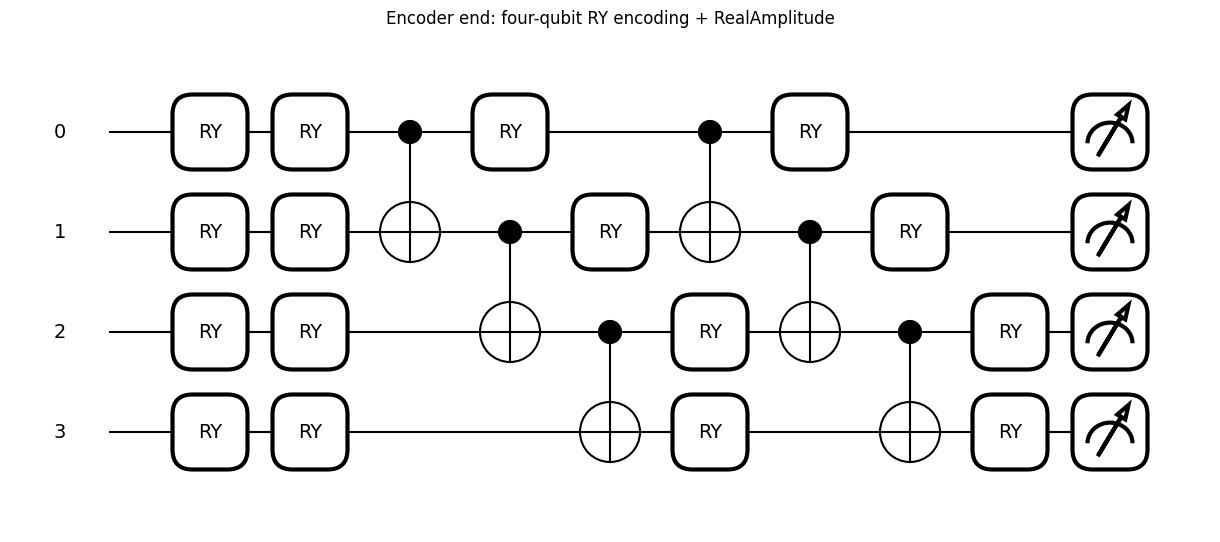

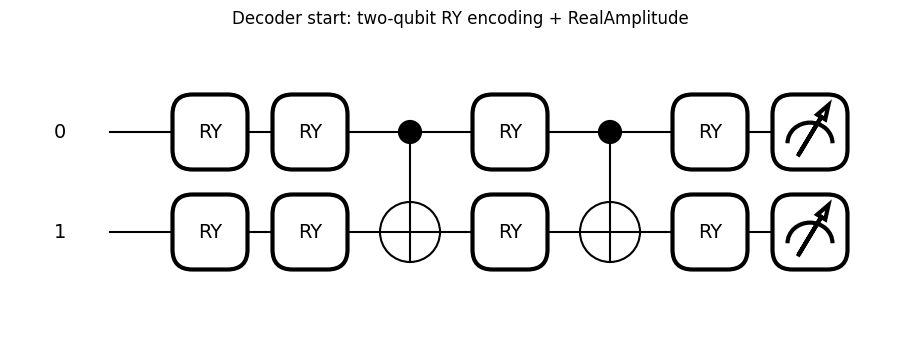

In [7]:
with torch.no_grad():
    encoder_angles = torch.pi * torch.tanh(model.encoder_classical(X_train[:1]))
    example_mu, _ = model.encode(X_train[:1])
    decoder_angles = (torch.pi / 2) * torch.tanh(example_mu)

fig, ax = qml.draw_mpl(model.encoder_quantum.qnode)(encoder_angles)
ax.set_title("Encoder end: four-qubit RY encoding + RealAmplitude")
plt.show()

fig, ax = qml.draw_mpl(model.decoder_quantum.qnode)(decoder_angles)
ax.set_title("Decoder start: two-qubit RY encoding + RealAmplitude")
plt.show()


## Reconstruction and KL loss

The VAE loss combines reconstruction error and a Gaussian KL term [1]:

$$\mathcal{L}_{rec}=\frac{1}{2\sigma_{obs}^2}\sum_p(x_p-\hat{x}_p)^2,$$
$$\mathcal{L}_{KL}=\frac12\sum_j\left(\mu_j^2+\exp(\mathrm{logvar}_j)-1-\mathrm{logvar}_j\right).$$

Average both terms over the batch. Use `observation_std=0.2` and train with `reconstruction + beta * KL`, increasing `beta` to 1 over 20 epochs. The reconstruction term is a fixed-variance Gaussian negative log likelihood, with its constant omitted.

In [8]:
observation_std = 0.2

def kl_per_dimension(mu, logvar):
    return 0.5 * (mu.square() + logvar.exp() - 1 - logvar)

def loss_terms(reconstruction, target, mu, logvar):
    reconstruction_loss = (
        (reconstruction - target).square().sum(dim=-1) / (2 * observation_std**2)
    ).mean()
    kl_loss = kl_per_dimension(mu, logvar).sum(dim=-1).mean()
    return reconstruction_loss, kl_loss


In [9]:
# Check reconstruction gradients, without relying on the encoder KL term.
model.zero_grad()
torch.manual_seed(seed)
probe_x = X_train[:8].clone().requires_grad_(True)
probe_reconstruction, probe_mu, probe_logvar = model(probe_x)
probe_rec, probe_kl = loss_terms(probe_reconstruction, probe_x.detach(), probe_mu, probe_logvar)
probe_rec.backward()
assert probe_reconstruction.shape == probe_x.shape
assert probe_mu.shape == probe_logvar.shape == (8, model.latent_dim)
assert model.encoder_quantum.feature_map.params is None
assert model.decoder_quantum.feature_map.params is None
assert model.encoder_quantum.ansatz.params is not model.decoder_quantum.ansatz.params
for name, params in model.named_parameters():
    assert params.grad is not None and torch.isfinite(params.grad).all(), name
    assert params.grad.norm() > 0, name
for name in ("encoder_quantum", "decoder_quantum"):
    params = getattr(model, name).ansatz.params
    print(f"{name} gradient norm: {params.grad.norm().item():.6f}")
assert probe_x.grad is not None and torch.isfinite(probe_x.grad).all()
print(f"Input gradient norm: {probe_x.grad.norm().item():.6f}")
with torch.no_grad():
    assert model.decode(torch.zeros(3, 5, model.latent_dim, dtype=dtype)).shape == (3, 5, 64)
model.zero_grad()


encoder_quantum gradient norm: 16.908446
decoder_quantum gradient norm: 6.568261
Input gradient norm: 4.054962


## Training

Use validation loss to select the checkpoint after the KL warm-up. Validation uses eight fixed latent draws per image; test data is not used for selection.

In [10]:
@torch.no_grad()
def evaluate(model, images, evaluation_seed, draws=8):
    model.eval()
    mu, logvar = model.encode(images)
    generator = torch.Generator().manual_seed(evaluation_seed)
    noise = torch.randn((draws, len(images), model.latent_dim), generator=generator, dtype=dtype)
    z = mu.unsqueeze(0) + torch.exp(0.5 * logvar).unsqueeze(0) * noise
    reconstructions = model.decode(z)
    rec_loss = (
        (reconstructions - images.unsqueeze(0)).square().sum(dim=-1) / (2 * observation_std**2)
    ).mean().item()
    kl_loss = kl_per_dimension(mu, logvar).sum(dim=-1).mean().item()
    mean_reconstruction = model.decode(mu)
    mean_mse = (mean_reconstruction - images).square().mean().item()
    return {"total": rec_loss + kl_loss, "reconstruction": rec_loss, "kl": kl_loss, "mean_mse": mean_mse}


In [12]:
torch.manual_seed(seed + 1)
optimizer = Adam(model.parameters(), lr=0.01)
total_epochs = 450
warmup_epochs = 20
history = {"train_reconstruction": [], "train_kl": [], "validation_total": [], "validation_reconstruction": [], "validation_kl": []}
best_loss = float("inf")
best_state = None
best_epoch = 0
initial_validation = evaluate(model, X_validation, seed + 100)

for epoch in range(1, total_epochs + 1):
    beta = min(1.0, epoch / warmup_epochs)
    model.train()
    total_rec, total_kl = 0.0, 0.0
    for (batch_x,) in train_loader:
        optimizer.zero_grad()
        reconstruction, mu, logvar = model(batch_x)
        rec_loss, kl_loss = loss_terms(reconstruction, batch_x, mu, logvar)
        loss = rec_loss + beta * kl_loss
        loss.backward()
        optimizer.step()
        total_rec += rec_loss.item() * len(batch_x)
        total_kl += kl_loss.item() * len(batch_x)

    validation = evaluate(model, X_validation, seed + 100)
    history["train_reconstruction"].append(total_rec / len(X_train))
    history["train_kl"].append(total_kl / len(X_train))
    for key in ("total", "reconstruction", "kl"):
        history["validation_" + key].append(validation[key])

    if epoch >= warmup_epochs and validation["total"] < best_loss:
        best_loss = validation["total"]
        best_epoch = epoch
        best_state = {name: value.detach().clone() for name, value in model.state_dict().items()}
    if epoch == 1 or epoch % 30 == 0:
        print(f"Epoch {epoch:3}/{total_epochs} | beta={beta:.2f} | "
              f"validation reconstruction={validation['reconstruction']:.3f}, "
              f"KL={validation['kl']:.3f}, total={validation['total']:.3f}")

model.load_state_dict(best_state)
model.eval()
print(f"Selected epoch {best_epoch}: validation objective = {best_loss:.4f}")


Epoch   1/450 | beta=0.05 | validation reconstruction=18.668, KL=3.326, total=21.994
Epoch  30/450 | beta=1.00 | validation reconstruction=19.587, KL=3.222, total=22.810
Epoch  60/450 | beta=1.00 | validation reconstruction=20.255, KL=3.483, total=23.737
Epoch  90/450 | beta=1.00 | validation reconstruction=19.191, KL=3.399, total=22.590
Epoch 120/450 | beta=1.00 | validation reconstruction=19.195, KL=3.404, total=22.598
Epoch 150/450 | beta=1.00 | validation reconstruction=19.409, KL=3.480, total=22.888
Epoch 180/450 | beta=1.00 | validation reconstruction=17.630, KL=3.527, total=21.157
Epoch 210/450 | beta=1.00 | validation reconstruction=17.585, KL=3.578, total=21.163
Epoch 240/450 | beta=1.00 | validation reconstruction=18.444, KL=3.419, total=21.862
Epoch 270/450 | beta=1.00 | validation reconstruction=20.199, KL=3.606, total=23.805
Epoch 300/450 | beta=1.00 | validation reconstruction=17.509, KL=3.326, total=20.835
Epoch 330/450 | beta=1.00 | validation reconstruction=17.202, KL=

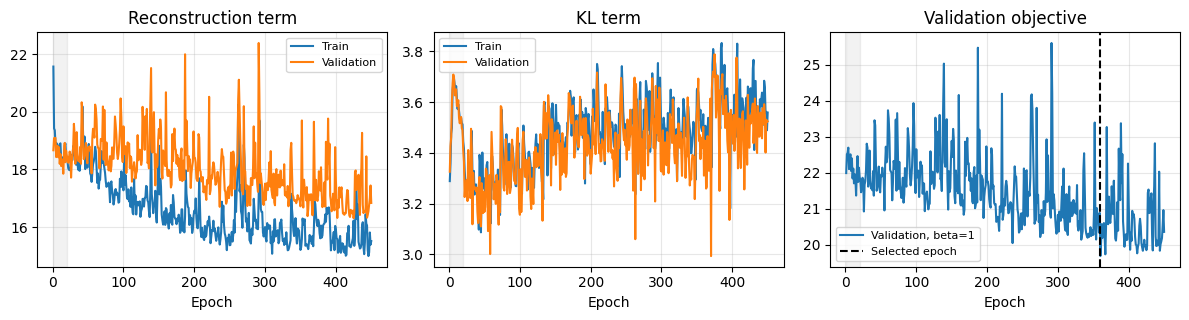

In [13]:
epochs = range(1, total_epochs + 1)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.3))
axes[0].plot(epochs, history["train_reconstruction"], label="Train")
axes[0].plot(epochs, history["validation_reconstruction"], label="Validation")
axes[0].set_title("Reconstruction term")
axes[1].plot(epochs, history["train_kl"], label="Train")
axes[1].plot(epochs, history["validation_kl"], label="Validation")
axes[1].set_title("KL term")
axes[2].plot(epochs, history["validation_total"], label="Validation, beta=1")
axes[2].axvline(best_epoch, color="black", linestyle="--", label="Selected epoch")
axes[2].set_title("Validation objective")
for ax in axes:
    ax.axvspan(1, warmup_epochs, color="gray", alpha=0.1)
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## Test results

Compare `decode(mu)` reconstructions with the original images and a training-mean-image baseline.
Plot the posterior means and inspect KL values to check whether the latent representation is being used.

In [14]:
test_metrics = evaluate(model, X_test, seed + 200, draws=32)
with torch.no_grad():
    test_mu, test_logvar = model.encode(X_test)
    test_reconstruction = model.decode(test_mu)
    baseline_mse = (X_train.mean(dim=0) - X_test).square().mean().item()
    mean_kl_by_dimension = kl_per_dimension(test_mu, test_logvar).mean(dim=0)
    posterior_mean_std = test_mu.std(dim=0)

print(f"Test objective (32 draws, beta=1): {test_metrics['total']:.4f}")
print(f"Test reconstruction term: {test_metrics['reconstruction']:.4f}")
print(f"Test KL: {test_metrics['kl']:.4f}")
print(f"Posterior-mean reconstruction MSE: {test_metrics['mean_mse']:.5f}")
print(f"Training-mean-image baseline MSE: {baseline_mse:.5f}")
print("KL per latent coordinate:", mean_kl_by_dimension.tolist())
print("Posterior mean std per coordinate:", posterior_mean_std.tolist())


Test objective (32 draws, beta=1): 21.2574
Test reconstruction term: 17.8989
Test KL: 3.3585
Posterior-mean reconstruction MSE: 0.02149
Training-mean-image baseline MSE: 0.06794
KL per latent coordinate: [1.591386381690421, 1.767113489263468]
Posterior mean std per coordinate: [0.8211042444758813, 0.8947105338897862]


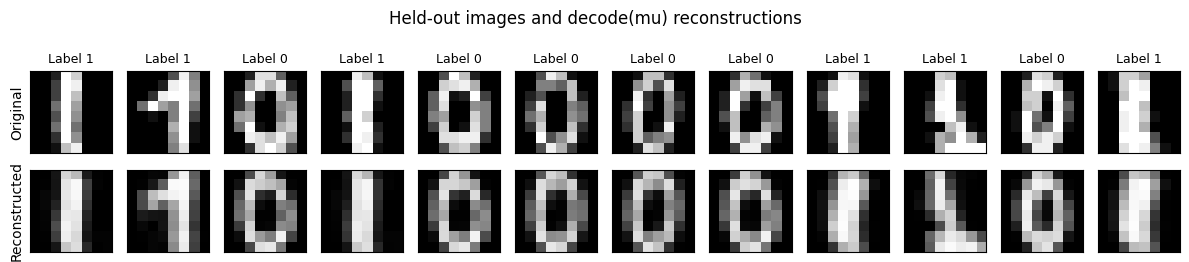

In [15]:
# Fixed test positions, not hand-picked reconstructions.
n_show = 12
fig, axes = plt.subplots(2, n_show, figsize=(12, 2.8))
for col in range(n_show):
    axes[0, col].imshow(X_test[col].reshape(8, 8), cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(f"Label {labels_test[col].item()}", fontsize=9)
    axes[1, col].imshow(test_reconstruction[col].reshape(8, 8), cmap="gray", vmin=0, vmax=1)
    for row in range(2):
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])
axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Reconstructed")
fig.suptitle("Held-out images and decode(mu) reconstructions")
fig.tight_layout()
plt.show()


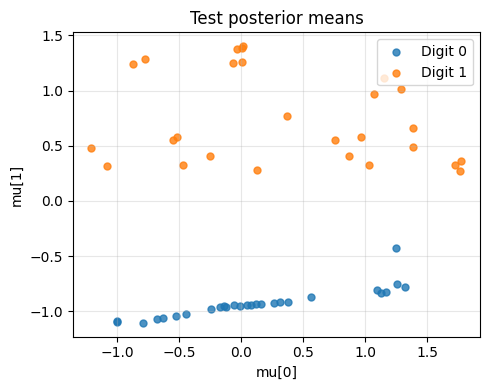

In [16]:
fig, ax = plt.subplots(figsize=(5, 4))
for label, color in [(0, "tab:blue"), (1, "tab:orange")]:
    points = test_mu[labels_test == label]
    ax.scatter(points[:, 0], points[:, 1], color=color, s=25, alpha=0.8, label=f"Digit {label}")
ax.set(title="Test posterior means", xlabel="mu[0]", ylabel="mu[1]")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


## Generate images

Sample `z` from `N(0, I)` and run the quantum and classical decoder. The encoder is not used.
The plots show decoder means without observation noise.

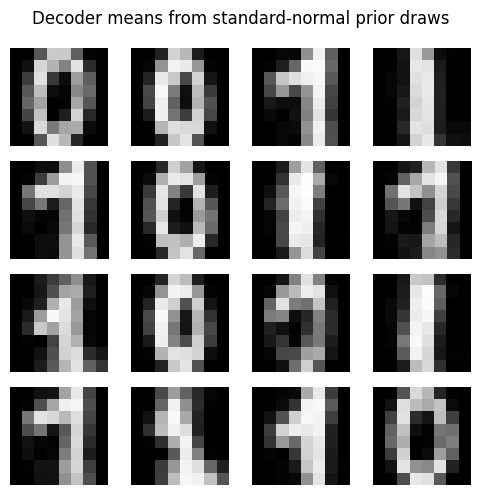

In [17]:
generation_generator = torch.Generator().manual_seed(seed + 300)
with torch.no_grad():
    prior_z = torch.randn((16, model.latent_dim), generator=generation_generator, dtype=dtype)
    generated_images = model.decode(prior_z)

fig, axes = plt.subplots(4, 4, figsize=(5, 5))
for ax, sample in zip(axes.flat, generated_images):
    ax.imshow(sample.reshape(8, 8), cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
fig.suptitle("Decoder means from standard-normal prior draws")
fig.tight_layout()
plt.show()


## Notes

The latent vector is classical; quantum states are not transferred between circuits. This small simulator example is not a quantum-advantage benchmark.

## References

[1] Kingma and Welling, [Auto-Encoding Variational Bayes](https://arxiv.org/abs/1312.6114), 2014.

[2] Khoshaman et al., [Quantum Variational Autoencoder](https://arxiv.org/abs/1802.05779), 2018.

[3] scikit-learn, [load_digits](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html).

[4] IBM Quantum, [real_amplitudes](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.real_amplitudes).